# 0.Basic
## 0.1.클래스  0, 1 예측 문제 해결: 이진 분류
## 0.2.클래스 3개 이상 문제 해결: 다중 분류

## 0.3.목표
- iris 데이터 이해하기
- 다중분류 문제를 해결해보자
- knn, tree 모델을 둘 다 사용해보자
  - 모델의 상세 정보는 다음 시간에~

# 1.라이브러리 불러오기


In [2]:
# 환경세팅
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 머신러닝 패키지(도구): aklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split



# 2.데이터셋 불러오기
- sklearn datasets에서 제공하는 붓꽃 품종 분류 데이터를 사용하자

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
# data: 문제, 특성(feature), 독립변수(indefendent), X 
# targe: 답, 레이블(Label), 종속변수, y
# frame:  
# target_names: 답(Label, 종속변수) 데이터의 이름들
# DESCR: describe 묘사하다, 기술하다 -> 데이터에 대한 설명(크기, 타입, 출처, 기술통계량) 
# feature_names: 특성(feature, 독립변수) 데이터의 이름들
# filename:
# data_module:

In [5]:
# iris 문제 데이터 접근
iris["data"] # 딕셔너리 일반적인 접근 가능
iris.data.shape # sklearn 데이터셋이라서 .으로도 접근 가능

# (150, 4)
# 150개의 꽃 데이터
# 150개의 꽃을 설명하기 위한 특성은 4개가 존재
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [6]:
iris.keys()
# 특성의 이름확인(컬럼명 확인)
iris.feature_names

# ['sepal length (cm)', : 꽃받침 길이
#  'sepal width (cm)',  : 꽃받침 너비
#  'petal length (cm)', : 꽃잎 길이
#  'petal width (cm)']  : 꽃입 너비
# -- 꽃을 설명하는데 꽃받침의 길이/너비, 꽃잎의 길이/너비가 영향을 줄 수 있을까? 학습이 될까?



['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
# 답 데이터 확인
iris.target

# array 자료형에서 카운팅 기능 연결
np.unique(iris.target, return_counts=True)
# 클래스 개수 : 3개 -> 다중분류


# array -> Series 변경해서 카운팅 기능 연결
# pd.Series(iris.target).value_counts()

(array([0, 1, 2]), array([50, 50, 50], dtype=int64))

In [8]:
# 답데이터의 이름 확인하기
iris.target_names
# 인덱스 위치로 매칭!
#  ['setosa',  : 0번
# 'versicolor',: 1번 
# 'virginica'] : 2번



array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
# DESCR
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

# 3.데이터 정리하기
- numpy -> df 변환해서 X,y 변수로 담아주기
- train, test용 분리(7:3): train_test_split
- 크기확인

In [10]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [11]:
iris.data[:5]
# X = 
X = pd.DataFrame(iris.data, columns= iris.feature_names) 
y = pd.Series(iris.target)

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [12]:
# train_test_split()
# 1) 랜덤하게 데이터 섞기
# 2) 지정된 비율로 분할(분리)
# X_train, X_test, y_train, Y_test = train_test_split(문제, 답, 분리비율, 랜덤섞는 고정값)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, train_size= 0.7, random_state = 7)

# 크기확인
print("훈련용:",X_train)
print("테스트용:",X_test)

훈련용:      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
49                 5.0               3.3                1.4               0.2
65                 6.7               3.1                4.4               1.4
62                 6.0               2.2                4.0               1.0
111                6.4               2.7                5.3               1.9
29                 4.7               3.2                1.6               0.2
..                 ...               ...                ...               ...
142                5.8               2.7                5.1               1.9
92                 5.8               2.6                4.0               1.2
103                6.3               2.9                5.6               1.8
67                 5.8               2.7                4.1               1.0
25                 5.0               3.0                1.6               0.2

[105 rows x 4 columns]
테스트용:      sepal length (cm)  sepal

In [13]:
y_train

49     0
65     1
62     1
111    2
29     0
      ..
142    2
92     1
103    2
67     1
25     0
Length: 105, dtype: int32

# 4.의사결정트리 모델링
- 모델 생성
- 모델 학습
- 모델 예측
- 모델 평가

In [14]:
# parameter max_depth = 4에서 1 over-fitting 과적합등을 설정
tree_model = DecisionTreeClassifier(max_depth = 1)
# 하이퍼 파라미터 => 모델의 복잡도를 제어 (과대Over fit, 과소Under fit, 일반화)
# knn: n_neighbors
# tree: max_depth (최대 깊이)

In [15]:
# 학습(Learning)
# 모델명.fit(훈련문제, 훈련답)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
# 예측(Prediction)
# 테스트용 문제
# 모델명.predict(테스트문제)
pred = tree_model.predict(X_test) # 예측은 항상 정답만 뽑아내는 것은 아니다! 틀릴 수 있음!

# 정확도 평가 : 86%
accuracy_score(y_test, pred)

# 100% 성능이 좋음을 의미하긴 함
# 그러나, 어떤 데이터가 들어가더라도 일반적인 좋은 성능을 내는 것이 중요함

# tree 모델의 특성 때문에 정확도가 다를 수 있음.
# -random하게 섞이는 기능이 내부적으로 수행됨 -> 학습하는 데이터의 순서가 다름-> 규칙이 조금씩은 다르게 정리 될 수 있다.

# 모델의 규칙이 train 데이터에 너무 fit 하게 학습했을 수 있음.=> over-fitting (과대적합)일 수 있음! so hyper parameter 필요.

0.6222222222222222

<function matplotlib.pyplot.show(close=None, block=None)>

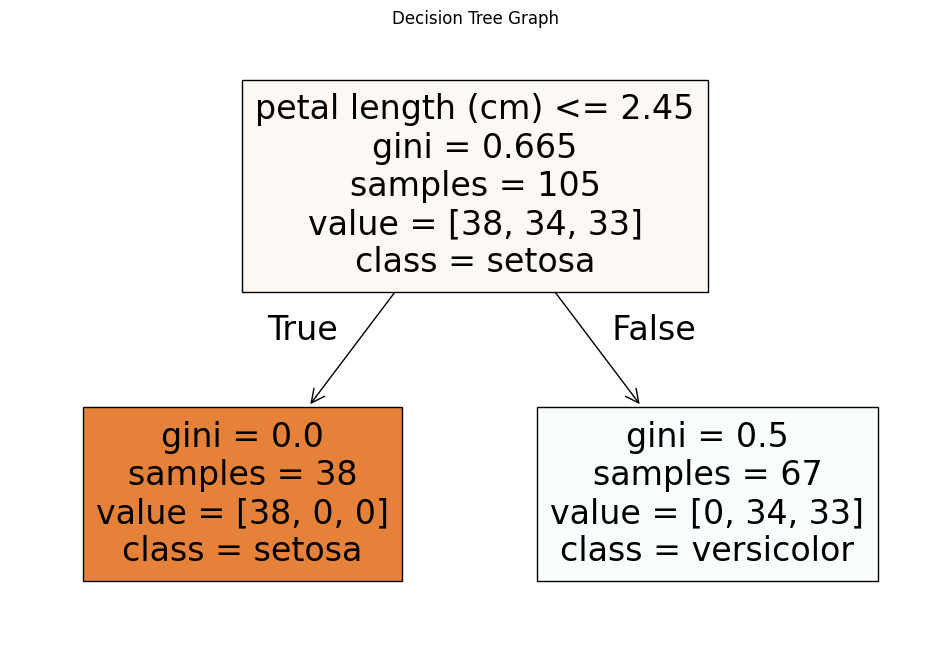

In [17]:
# 모델의 규칙 시각화
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(tree_model,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               filled=True)
plt.title("Decision Tree Graph")
plt.show